In [1]:
# =========================
# IMPORTS
# =========================
import os
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

In [2]:
TRAIN_CSV = Path("../data/processed/train.csv")
VAL_CSV = Path("../data/processed/validation.csv")

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

train_df.head()

Train shape: (2684, 3)
Validation shape: (671, 3)


,filepath,label,split
0,data/processed/train/BrownSpot/IMG_20190420_19...,BrownSpot,train
1,data/processed/train/BrownSpot/IMG_20190420_19...,BrownSpot,train
2,data/processed/train/BrownSpot/IMG_20190420_19...,BrownSpot,train
3,data/processed/train/BrownSpot/IMG_20190420_19...,BrownSpot,train
4,data/processed/train/BrownSpot/IMG_20190420_19...,BrownSpot,train


In [3]:
train_df["filepath"] = train_df["filepath"].str.replace(
    "data/processed/train", "data/raw/RiceLeafs/train", regex=False
)

val_df["filepath"] = val_df["filepath"].str.replace(
    "data/processed/validation", "data/raw/RiceLeafs/validation", regex=False
)

# Check
train_df.head()

,filepath,label,split
0,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train
1,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train
2,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train
3,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train
4,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train


In [4]:
IMG_SIZE = (224, 224)

def load_images(df, target_size=(224, 224)):
    images = []

    for path in df["filepath"]:
        full_path = os.path.join("..", path)

        if not os.path.exists(full_path):
            print(f"Missing file: {full_path}")
            continue

        try:
            img = Image.open(full_path).convert("RGB")
            img = img.resize(target_size)
            img = np.array(img, dtype=np.float32) / 255.0
            images.append(img)
        except Exception as e:
            print(f"Error loading {full_path}: {e}")

    return np.array(images)

In [5]:
train_df_sample = train_df.sample(1000, random_state=42)
val_df_sample = val_df.sample(300, random_state=42)

In [6]:
X_train = load_images(train_df_sample, IMG_SIZE)
X_val = load_images(val_df_sample, IMG_SIZE)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (1000, 224, 224, 3)
X_val shape: (300, 224, 224, 3)


In [7]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(train_df_sample["label"])
y_val = label_encoder.transform(val_df_sample["label"])

class_names = label_encoder.classes_
num_classes = len(class_names)

print("Classes:", class_names)

Classes: ['BrownSpot' 'Healthy' 'Hispa' 'LeafBlast']


In [8]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)

print("Flattened shape:", X_train_flat.shape)

rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_flat, y_train)

rf_pred = rf_model.predict(X_val_flat)

rf_acc = accuracy_score(y_val, rf_pred)
rf_f1 = f1_score(y_val, rf_pred, average="macro")

print("Random Forest Accuracy:", round(rf_acc, 4))
print("Random Forest Macro-F1:", round(rf_f1, 4))

Flattened shape: (1000, 150528)
Random Forest Accuracy: 0.1567
Random Forest Macro-F1: 0.131


In [9]:
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)

cnn_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = cnn_model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 202ms/step - accuracy: 0.4280 - loss: 1.7169 - val_accuracy: 0.4500 - val_loss: 1.3031
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 193ms/step - accuracy: 0.4700 - loss: 1.1825 - val_accuracy: 0.2500 - val_loss: 1.7198
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - accuracy: 0.5180 - loss: 1.0951 - val_accuracy: 0.2900 - val_loss: 1.4025
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 194ms/step - accuracy: 0.5620 - loss: 1.0100 - val_accuracy: 0.3633 - val_loss: 1.4814
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 195ms/step - accuracy: 0.5950 - loss: 0.9299 - val_accuracy: 0.4100 - val_loss: 1.5571


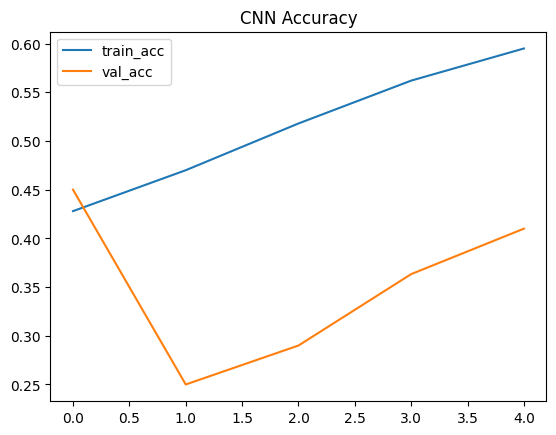

In [11]:
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("CNN Accuracy")
plt.show()

In [12]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# Predictions
cnn_val_probs = cnn_model.predict(X_val)
cnn_val_pred = np.argmax(cnn_val_probs, axis=1)

# Metrics
cnn_acc = accuracy_score(y_val, cnn_val_pred)
cnn_f1 = f1_score(y_val, cnn_val_pred, average="macro")

print("Simple CNN Accuracy:", round(cnn_acc, 4))
print("Simple CNN Macro-F1:", round(cnn_f1, 4))

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
Simple CNN Accuracy: 0.41
Simple CNN Macro-F1: 0.2681


In [13]:
results_df = pd.DataFrame({
    "Model": ["Random Forest", "Simple CNN"],
    "Accuracy": [rf_acc, cnn_acc],
    "Macro-F1": [rf_f1, cnn_f1]
})

results_df

,Model,Accuracy,Macro-F1
0,Random Forest,0.156667,0.130995
1,Simple CNN,0.410000,0.268081
